In [3]:
%cd ..

c:\Users\user\OneDrive\Desktop\170A-CHOC


In [50]:
import torch
import pandas as pd
import numpy as np
import random
import os
import torch.nn as nn
from torch.distributions import Beta
from functools import partial
from data.data_partitioner import DataPartitioner

In [6]:
def set_seed(seed=42):
    # 1. Basic Python and NumPy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    
    # 3. Force CuDNN to be deterministic (Note: this can slightly slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [55]:
def data_prep(df, drop, target):
    df_enc = pd.get_dummies(df).astype(int)
    return torch.tensor(df_enc.drop(drop, axis=1).values).float(), torch.tensor(df_enc[target].values).float()

In [56]:
choc_data_prep = partial(data_prep, drop=['no_show_Yes','no_show_No', 'NOSHOWS_365'], target='no_show_Yes')

In [57]:
data = DataPartitioner(data_dir='data')
data.load_datasets()

In [59]:
X_train, y_train = choc_data_prep(data.choc)
X_test, y_test = choc_data_prep(data.choc_svi[df.columns.tolist()])
X_eval, y_eval = choc_data_prep(data.choc_svi_coi[df.columns.tolist()])

In [ ]:
def forward_df(X, y, model):
    # 1. Get the tuple from the model
    alpha, beta, p_mean = model(X)

    # 2. Combine them with y_train into a single list
    # We ensure y_train is the correct shape using .view(-1)
    all_tensors = [alpha, beta, p_mean, y.view(-1)]

    # 3. Stack them horizontally, detach, and convert
    return pd.DataFrame(
        torch.stack(all_tensors, dim=1).detach().cpu().numpy(),
        columns=['alpha', 'beta', 'p_mean', 'no_show']
    )

In [ ]:
def result_aggregation(df):
    df['bin'] = pd.cut(df['p_mean'], 10)
    return df[['bin','no_show']].groupby('bin').agg(['size','mean'])

In [75]:
class BayesianWeightNet(nn.Module):
    def __init__(self):
        super(BayesianWeightNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(51, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)  # Two outputs: one for Alpha, one for Beta
        )

    def forward(self, X):
        # Pass features through the network
        out = self.net(X)
        
        # Split the output into Alpha and Beta components
        # out[:, 0] is Alpha, out[:, 1] is Beta
        # We use softplus to ensure alpha/beta > 0
        # Adding a small constant (1e-6) provides numerical stability
        alpha = nn.functional.softplus(out[:, 0]) + 1.0
        beta = nn.functional.softplus(out[:, 1]) + 1.0
        # 2. Multi-sample Thompson Sampling
        dist = torch.distributions.Beta(alpha, beta)
        
        # rsample with sample_shape=(100,)
        # Resulting shape: [100, batch_size, 1]
        samples = dist.rsample(sample_shape=torch.Size([100]))
        
        # Take the mean across the 100 samples (dim 0)
        # This reduces shape back to [batch_size, 1]
        p_sampled = samples.mean(dim=0)
        return alpha, beta, p_sampled

In [192]:
# 1. Setup ---
model = BayesianWeightNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.015)

# Assuming X_train and y_train are your tensors
dataset = torch.utils.data.TensorDataset(X_train, y_train)

In [193]:
# from torch.utils.data import WeightedRandomSampler

# Create weights for every individual sample in the dataset
# 1/12 for minority, 1/88 for majority
# weights = [1/12 if label == 1 else 1/88 for label in y_train]
# sampler = WeightedRandomSampler(weights, len(weights))

# Your loader will now see 50% zeros and 50% ones in every batch
loader = torch.utils.data.DataLoader(dataset, batch_size=32, 
                                    #  sampler=sampler
                                     )
model.train()

BayesianWeightNet(
  (net): Sequential(
    (0): Linear(in_features=51, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [194]:
# Calculate weight: 88 / 12 = 7.33
# This tells the model: "A mistake on a '1' is 7.33x more important than a '0'"
pos_weight = torch.tensor([7.33]) 

# Use the BCEWithLogits equivalent or functional version with manual weighting
def weighted_bce(prediction, target, pos_weight):
    # Standard BCE is: -(target * log(p) + (1-target) * log(1-p))
    # Weighted BCE is: -(target * log(p) * pos_weight + (1-target) * log(1-p))
    loss = -(target * torch.log(prediction) * pos_weight + (1 - target) * torch.log(1 - prediction))
    return loss.mean()

In [ ]:
epochs = 5
for epoch in range(epochs):
    epoch_loss = 0.0
    
    for X_batch, target_batch in loader:
        optimizer.zero_grad()

        # 1. Forward pass
        alpha, beta, p_sampled = model(X_batch)

        # 3. Binary Cross Entropy Loss
        p_sampled = torch.clamp(p_sampled, 1e-7, 1.0 - 1e-7)
        loss = nn.functional.binary_cross_entropy(p_sampled, target_batch)

        # 4. Backward pass
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss/len(loader):.4f}")

Epoch 1/5 | Loss: 1.2422
Epoch 2/5 | Loss: 1.2441
Epoch 3/5 | Loss: 1.2413
Epoch 4/5 | Loss: 1.2405
Epoch 5/5 | Loss: 1.2438


In [196]:
model.forward(X_train)

(tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        grad_fn=<AddBackward0>),
 tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        grad_fn=<AddBackward0>),
 tensor([0.5214, 0.4666, 0.5230,  ..., 0.4605, 0.4400, 0.5147],
        grad_fn=<MeanBackward1>))

In [197]:
forward_choc_df = partial(forward_df, model=model)

In [198]:
df = forward_choc_df(X=X_train, y=y_train)

In [199]:
result_aggregation(df)

C:\Users\user\AppData\Local\Temp\ipykernel_22068\3135445507.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df[['bin','no_show']].groupby('bin').agg(['size','mean'])


no_show          
                  size      mean
bin                             
(0.362, 0.388]       5  0.400000
(0.388, 0.413]      32  0.125000
(0.413, 0.438]     424  0.134434
(0.438, 0.463]    2559  0.125440
(0.463, 0.488]    7506  0.120837
(0.488, 0.513]   10469  0.121979
(0.513, 0.539]    7186  0.129140
(0.539, 0.564]    2392  0.136706
(0.564, 0.589]     379  0.160950
(0.589, 0.614]      25  0.160000

In [187]:
df_test = forward_choc_df(X_test,y_test)

In [188]:
result_aggregation(df_test)

C:\Users\user\AppData\Local\Temp\ipykernel_22068\3135445507.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df[['bin','no_show']].groupby('bin').agg(['size','mean'])


no_show          
                  size      mean
bin                             
(0.515, 0.564]       2  0.000000
(0.564, 0.612]       0       NaN
(0.612, 0.66]        0       NaN
(0.66, 0.709]        0       NaN
(0.709, 0.757]       0       NaN
(0.757, 0.805]     350  0.060000
(0.805, 0.853]   44209  0.082992
(0.853, 0.901]    5813  0.105625
(0.901, 0.95]    17008  0.150223
(0.95, 0.998]      809  0.815822

In [189]:
df_eval = forward_choc_df(X_eval,y_eval)

In [190]:
result_aggregation(df_eval)

C:\Users\user\AppData\Local\Temp\ipykernel_22068\3135445507.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df[['bin','no_show']].groupby('bin').agg(['size','mean'])


no_show          
                  size      mean
bin                             
(0.513, 0.562]      16  0.000000
(0.562, 0.61]        1  0.000000
(0.61, 0.659]        0       NaN
(0.659, 0.707]       0       NaN
(0.707, 0.756]       0       NaN
(0.756, 0.804]    1760  0.086932
(0.804, 0.853]  243928  0.090240
(0.853, 0.901]   36864  0.114176
(0.901, 0.95]   173416  0.165250
(0.95, 0.998]     3400  0.770000

Brier Score: 0.6653
ROC-AUC: 0.6057
Log-Loss: 1.8614


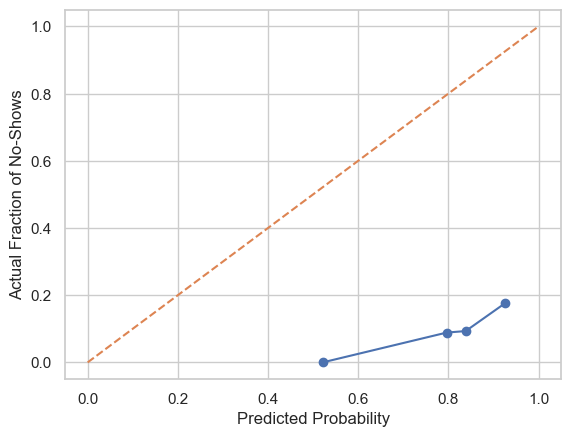

In [191]:
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
y_true = df_eval['no_show']
y_prob = df_eval['p_mean']
# Metrics
print(f"Brier Score: {brier_score_loss(y_true, y_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"Log-Loss: {log_loss(y_true, y_prob):.4f}")

# Calibration Plot
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Fraction of No-Shows")
plt.show()